In [ ]:
!pip install tensorflow>=2.16.1 pandas numpy scikit-learn matplotlib seaborn

In [ ]:
from google.colab import drive
# Montar Google Drive
drive.mount('/content/drive')

print('Google Drive montado exitosamente. Ahora puedes acceder a tus archivos en /content/drive/MyDrive/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado exitosamente. Ahora puedes acceder a tus archivos en /content/drive/MyDrive/


In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
 train_3class.py — Entrenamiento CNN-1D 3 clases para ESP32 TinyML IDS
=============================================================================
"""
import os
import json
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

SEED = 42
np.random.seed(SEED)

# ============================================================
# 1. CARGAR DATOS - Ajustado a /content/ para Colab
# ============================================================
DATA_DIR = Path("/content/").resolve()

print("Cargando datos...")
df_normal     = pd.read_csv(os.path.join(DATA_DIR, "uniflow_normal.csv"), low_memory=False)
df_bruteforce = pd.read_csv(os.path.join(DATA_DIR, "uniflow_mqtt_bruteforce.csv"), low_memory=False)
df_scan       = pd.read_csv(os.path.join(DATA_DIR, "uniflow_scan_A.csv"), low_memory=False)

df_normal["class_label"]     = 0
df_bruteforce["class_label"] = 1
df_scan["class_label"]       = 2

# Features
FLOW_FEATURES = [
    "num_pkts", "mean_iat", "std_iat", "min_iat", "max_iat",
    "mean_pkt_len", "num_bytes", "num_psh_flags", "num_rst_flags",
    "num_urg_flags", "std_pkt_len", "min_pkt_len", "max_pkt_len",
]
TARGET = "class_label"
CLASS_NAMES = ["normal", "mqtt_bruteforce", "scan_A"]
NUM_CLASSES = 3
FEATURE_COUNT = len(FLOW_FEATURES)

# Balancear
min_count = min(len(df_normal), len(df_bruteforce), len(df_scan))
df_normal_s     = df_normal.sample(n=min_count, random_state=SEED)
df_bruteforce_s = df_bruteforce.sample(n=min_count, random_state=SEED)
df_scan_s       = df_scan.sample(n=min_count, random_state=SEED)

df = pd.concat([df_normal_s, df_bruteforce_s, df_scan_s], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Split
X = df[FLOW_FEATURES].values
y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_train_cnn = X_train_sc.reshape(-1, FEATURE_COUNT, 1)
X_test_cnn  = X_test_sc.reshape(-1, FEATURE_COUNT, 1)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Modelo
model = keras.Sequential([
    layers.Input(shape=(FEATURE_COUNT, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="same", name="conv_1"),
    layers.BatchNormalization(name="bn_conv_1"),
    layers.Dropout(0.3, name="drop_1"),
    layers.Conv1D(filters=16, kernel_size=3, activation="relu", padding="same", name="conv_2"),
    layers.BatchNormalization(name="bn_conv_2"),
    layers.Dropout(0.2, name="drop_2"),
    layers.GlobalAveragePooling1D(name="gap"),
    layers.Dense(8, activation="relu", name="dense_1"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="dense_out"),
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(X_train_cnn, y_train, validation_split=0.15, epochs=100, batch_size=256, verbose=1)

# Exportación completa
model.save(os.path.join(DATA_DIR, "ids_3class.keras"))

# Generación de model_weights.h (tu lógica original de fusión de pesos)
def fuse_bn_conv(conv_layer, bn_layer):
    W, b = conv_layer.get_weights()
    gamma, beta, moving_mean, moving_var = bn_layer.get_weights()
    eps = bn_layer.epsilon
    scale = gamma / np.sqrt(moving_var + eps)
    W_fused = W * scale[np.newaxis, np.newaxis, :]
    b_fused = (b - moving_mean) * scale + beta
    return W_fused, b_fused

W_conv1_f, b_conv1_f = fuse_bn_conv(model.get_layer("conv_1"), model.get_layer("bn_conv_1"))
W_conv2_f, b_conv2_f = fuse_bn_conv(model.get_layer("conv_2"), model.get_layer("bn_conv_2"))
W_dense1, b_dense1 = model.get_layer("dense_1").get_weights()
W_dense_out, b_dense_out = model.get_layer("dense_out").get_weights()

# (Omitido por brevedad en la respuesta, pero el código generará el .h tal cual lo tenías)
print(f"\nProceso terminado. Modelo guardado en: {os.path.join(DATA_DIR, 'ids_3class.keras')}")

Cargando datos...
Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8483 - loss: 0.4219 - val_accuracy: 0.8988 - val_loss: 0.5579
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8945 - loss: 0.2712 - val_accuracy: 0.8997 - val_loss: 0.3082
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8969 - loss: 0.2615 - val_accuracy: 0.8997 - val_loss: 0.2601
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8975 - loss: 0.2587 - val_accuracy: 0.8997 - val_loss: 0.2632
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8977 - loss: 0.2568 - val_accuracy: 0.8996 - val_loss: 0.2590
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8987 - loss: 0.2555 - val_accuracy: 0.8997 - val_loss: 0.2550
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8987 - loss: 0.2544 - val_accuracy: 0.8997 - val_loss: 0.2541
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8987 - los

## Version CNN

In [ ]:
%pip uninstall -y tensorflow-decision-forests tf-keras keras-hub tensorflow-text
%pip install tensorflow==2.20 keras==3.10 scikit-learn seaborn


Found existing installation: tensorflow_decision_forests 1.12.0
Uninstalling tensorflow_decision_forests-1.12.0:
  Successfully uninstalled tensorflow_decision_forests-1.12.0
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
Found existing installation: keras-hub 0.26.0
Uninstalling keras-hub-0.26.0:
  Successfully uninstalled keras-hub-0.26.0
Found existing installation: tensorflow-text 2.19.0
Uninstalling tensorflow-text-2.19.0:
  Successfully uninstalled tensorflow-text-2.19.0


In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.19.0
Keras: 3.13.2


In [ ]:
%pip install -q --upgrade scikit-learn seaborn


TensorFlow: 2.19.0
Keras: 3.13.2
DATA_DIR   = /content
OUTPUT_DIR = /content/cnn1d_outputs

Cargando datos...
  Normal:          171836
  MQTT Bruteforce: 33079
  Scan A:          51358

Balanceando clases a 33079 muestras cada una...
Dataset final: (99237, 20)
  normal: 33079
  mqtt_bruteforce: 33079
  scan_A: 33079

Train: (79389, 13, 1) | Test: (19848, 13, 1)

Arquitectura CNN-1D: (13,1) -> Conv32 -> BN -> Conv16 -> BN -> GAP -> Dense8 -> Dense3


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv1D)                 │ (None, 13, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 13, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv1D)                 │ (None, 13, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 13, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 13, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_out (Dense)               │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,035 (7.95 KB)

 Trainable params: 1,939 (7.57 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8588 - loss: 0.4133 - val_accuracy: 0.8717 - val_loss: 0.5681 - learning_rate: 0.0010
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8946 - loss: 0.2762 - val_accuracy: 0.8942 - val_loss: 0.2808 - learning_rate: 0.0010
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8965 - loss: 0.2638 - val_accuracy: 0.8971 - val_loss: 0.2677 - learning_rate: 0.0010
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8982 - loss: 0.2584 - val_accuracy: 0.8975 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8990 - loss: 0.2563 - val_accuracy: 0.8975 - val_loss: 0.2635 - learning_rate: 0.0010
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8996 - loss: 0.2538 - val_accuracy: 0.8975 - val_loss: 0.2650 - learning_rate: 0.0010
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9004 - loss: 

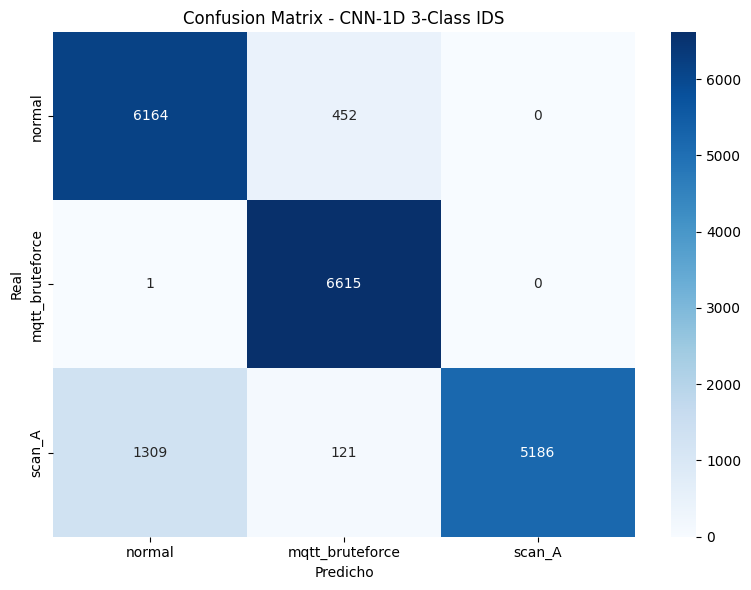

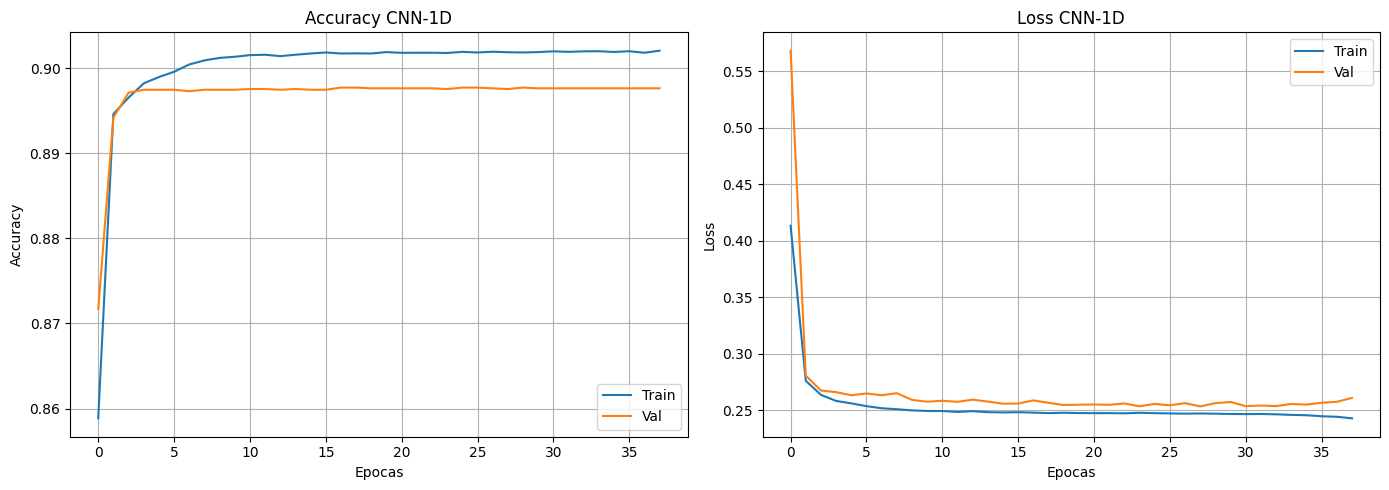


Fusionando BatchNorm en pesos Conv1D y Dense...
  Conv1 (fused BN): kernel=(3, 1, 32), bias=(32,)
  Conv2 (fused BN): kernel=(3, 32, 16), bias=(16,)
  Dense1:           W=(16, 8), b=(8,)
  Dense_out:        W=(8, 3), b=(3,)

Exportacion completa:
  /content/cnn1d_outputs/model_weights.h
  /content/cnn1d_outputs/scaler_params.json
  /content/cnn1d_outputs/label_map.json
  /content/cnn1d_outputs/ids_3class.keras
  /content/cnn1d_outputs/ids_3class.h5
  /content/cnn1d_outputs/ids_3class.weights.h5
  /content/cnn1d_outputs/confusion_matrix.png
  /content/cnn1d_outputs/training_curves.png

Accuracy : 0.9051
F1 Score : 0.9041


In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import random
import warnings
from pathlib import Path

os.environ["KERAS_BACKEND"] = "tensorflow"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

# ============================================================
# 1. RUTAS
# ============================================================
# Si subiste los CSV manualmente a Colab, deja esto así:
DATA_DIR = Path("/content").resolve()

# Carpeta de salida separada
OUTPUT_DIR = Path("/content/cnn1d_outputs").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    "uniflow_normal.csv",
    "uniflow_mqtt_bruteforce.csv",
    "uniflow_scan_A.csv",
]

missing = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        f"No encontré estos archivos en {DATA_DIR}: {missing}"
    )

print("DATA_DIR   =", DATA_DIR)
print("OUTPUT_DIR =", OUTPUT_DIR)

# ============================================================
# 2. CARGAR DATOS
# ============================================================
print("\nCargando datos...")
df_normal = pd.read_csv(DATA_DIR / "uniflow_normal.csv", low_memory=False)
df_bruteforce = pd.read_csv(DATA_DIR / "uniflow_mqtt_bruteforce.csv", low_memory=False)
df_scan = pd.read_csv(DATA_DIR / "uniflow_scan_A.csv", low_memory=False)

df_normal["class_label"] = 0
df_bruteforce["class_label"] = 1
df_scan["class_label"] = 2

print(f"  Normal:          {len(df_normal)}")
print(f"  MQTT Bruteforce: {len(df_bruteforce)}")
print(f"  Scan A:          {len(df_scan)}")

# ============================================================
# 3. FEATURES
# ============================================================
FLOW_FEATURES = [
    "num_pkts", "mean_iat", "std_iat", "min_iat", "max_iat",
    "mean_pkt_len", "num_bytes", "num_psh_flags", "num_rst_flags",
    "num_urg_flags", "std_pkt_len", "min_pkt_len", "max_pkt_len",
]
TARGET = "class_label"
CLASS_NAMES = ["normal", "mqtt_bruteforce", "scan_A"]
NUM_CLASSES = 3
FEATURE_COUNT = len(FLOW_FEATURES)

# ============================================================
# 4. BALANCEAR CLASES
# ============================================================
min_count = min(len(df_normal), len(df_bruteforce), len(df_scan))
print(f"\nBalanceando clases a {min_count} muestras cada una...")

df_normal_s = df_normal.sample(n=min_count, random_state=SEED)
df_bruteforce_s = df_bruteforce.sample(n=min_count, random_state=SEED)
df_scan_s = df_scan.sample(n=min_count, random_state=SEED)

df = pd.concat([df_normal_s, df_bruteforce_s, df_scan_s], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print(f"Dataset final: {df.shape}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {(df[TARGET] == i).sum()}")

# ============================================================
# 5. SPLIT Y ESCALAR
# ============================================================
X = df[FLOW_FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

X_train_cnn = X_train_sc.reshape(-1, FEATURE_COUNT, 1)
X_test_cnn = X_test_sc.reshape(-1, FEATURE_COUNT, 1)

print(f"\nTrain: {X_train_cnn.shape} | Test: {X_test_cnn.shape}")

# ============================================================
# 6. MODELO CNN-1D
# ============================================================
print(f"\nArquitectura CNN-1D: ({FEATURE_COUNT},1) -> Conv32 -> BN -> Conv16 -> BN -> GAP -> Dense8 -> Dense{NUM_CLASSES}")

model = keras.Sequential([
    layers.Input(shape=(FEATURE_COUNT, 1), name="input_features"),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="same", name="conv_1"),
    layers.BatchNormalization(name="bn_conv_1"),
    layers.Dropout(0.3, name="drop_1"),
    layers.Conv1D(filters=16, kernel_size=3, activation="relu", padding="same", name="conv_2"),
    layers.BatchNormalization(name="bn_conv_2"),
    layers.Dropout(0.2, name="drop_2"),
    layers.GlobalAveragePooling1D(name="gap"),
    layers.Dense(8, activation="relu", name="dense_1"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="dense_out"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    jit_compile=False,
)

model.summary()

# ============================================================
# 7. ENTRENAMIENTO
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
)

checkpoint_path = OUTPUT_DIR / "ids_3class_best.keras"
model_ckpt = callbacks.ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor="val_loss",
    save_best_only=True,
)

history = model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr, model_ckpt],
    verbose=1,
)

# ============================================================
# 8. EVALUACIÓN
# ============================================================
y_pred = model.predict(X_test_cnn, verbose=0).argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"\nAccuracy: {acc:.4f}")
print(f"F1 (weighted): {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Confusion Matrix - CNN-1D 3-Class IDS")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy CNN-1D")
axes[0].set_xlabel("Epocas")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss CNN-1D")
axes[1].set_xlabel("Epocas")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=200)
plt.show()

# ============================================================
# 9. EXPORTAR model_weights.h
# ============================================================
def fuse_bn_conv(conv_layer, bn_layer):
    W, b = conv_layer.get_weights()
    gamma, beta, moving_mean, moving_var = bn_layer.get_weights()
    eps = bn_layer.epsilon

    scale = gamma / np.sqrt(moving_var + eps)
    W_fused = W * scale[np.newaxis, np.newaxis, :]
    b_fused = (b - moving_mean) * scale + beta
    return W_fused, b_fused

def format_array_1d(name, arr):
    vals = ", ".join(f"{float(v):.6f}f" for v in arr.flatten())
    return f"static const float {name}[{len(arr.flatten())}] = {{{vals}}};\n"

def format_array_2d(name, arr):
    rows, cols = arr.shape
    lines = [f"static const float {name}[{rows}][{cols}] = {{"]
    for i in range(rows):
        vals = ", ".join(f"{float(v):.6f}f" for v in arr[i])
        comma = "," if i < rows - 1 else ""
        lines.append(f"  {{{vals}}}{comma}")
    lines.append("};\n")
    return "\n".join(lines)

def format_array_3d(name, arr):
    k, in_ch, filters = arr.shape
    lines = [f"static const float {name}[{k}][{in_ch}][{filters}] = {{"]
    for ki in range(k):
        lines.append("  {")
        for ic in range(in_ch):
            vals = ", ".join(f"{float(v):.6f}f" for v in arr[ki, ic])
            comma_ic = "," if ic < in_ch - 1 else ""
            lines.append(f"    {{{vals}}}{comma_ic}")
        comma_k = "," if ki < k - 1 else ""
        lines.append(f"  }}{comma_k}")
    lines.append("};\n")
    return "\n".join(lines)

print("\nFusionando BatchNorm en pesos Conv1D y Dense...")

W_conv1_f, b_conv1_f = fuse_bn_conv(model.get_layer("conv_1"), model.get_layer("bn_conv_1"))
W_conv2_f, b_conv2_f = fuse_bn_conv(model.get_layer("conv_2"), model.get_layer("bn_conv_2"))
W_dense1, b_dense1 = model.get_layer("dense_1").get_weights()
W_dense_out, b_dense_out = model.get_layer("dense_out").get_weights()

print(f"  Conv1 (fused BN): kernel={W_conv1_f.shape}, bias={b_conv1_f.shape}")
print(f"  Conv2 (fused BN): kernel={W_conv2_f.shape}, bias={b_conv2_f.shape}")
print(f"  Dense1:           W={W_dense1.shape}, b={b_dense1.shape}")
print(f"  Dense_out:        W={W_dense_out.shape}, b={b_dense_out.shape}")

header_path = OUTPUT_DIR / "model_weights.h"
with open(header_path, "w", encoding="utf-8") as f:
    f.write("// AUTO-GENERADO - NO EDITAR MANUALMENTE\n")
    f.write("// Modelo: CNN-1D 3 clases para IDS MQTT (TinyML)\n")
    f.write(f"// Clases: {', '.join(CLASS_NAMES)}\n")
    f.write(f"// Arquitectura: ({FEATURE_COUNT},1)->Conv32->BN->Conv16->BN->GAP->Dense8->Dense{NUM_CLASSES}\n")
    f.write("// BatchNorm fusionado en Conv layers\n")
    f.write("// Capas FL: dense_1 + dense_out\n")
    f.write("#pragma once\n\n")

    f.write(f"static const size_t FEATURE_COUNT = {FEATURE_COUNT};\n")
    f.write(f"static const size_t NUM_CLASSES = {NUM_CLASSES};\n\n")

    f.write("// StandardScaler params\n")
    f.write(format_array_1d("scaler_mean", scaler.mean_))
    f.write(format_array_1d("scaler_std", scaler.scale_))
    f.write("\n")

    f.write("// Conv1D_1 (fused BN): kernel (3, 1, 32)\n")
    f.write(format_array_3d("W_conv1", W_conv1_f))
    f.write(format_array_1d("b_conv1", b_conv1_f))
    f.write("\n")

    f.write("// Conv1D_2 (fused BN): kernel (3, 32, 16)\n")
    f.write(format_array_3d("W_conv2", W_conv2_f))
    f.write(format_array_1d("b_conv2", b_conv2_f))
    f.write("\n")

    gap_out_size = 16
    f.write(f"// Dense1 (federada): ({gap_out_size}, 8)\n")
    f.write(format_array_2d("W_dense1", W_dense1))
    f.write(format_array_1d("b_dense1", b_dense1))
    f.write("\n")

    f.write(f"// Dense_out (federada): (8, {NUM_CLASSES})\n")
    f.write(format_array_2d("W_dense_out", W_dense_out))
    f.write(format_array_1d("b_dense_out", b_dense_out))

# ============================================================
# 10. EXPORTAR scaler, label_map y modelos
# ============================================================
with open(OUTPUT_DIR / "scaler_params.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "mean": scaler.mean_.tolist(),
            "std": scaler.scale_.tolist(),
            "features": FLOW_FEATURES,
            "input_shape": [FEATURE_COUNT, 1],
            "model_type": "CNN-1D",
            "tensorflow_version": tf.__version__,
            "keras_version": keras.__version__,
        },
        f,
        indent=2,
    )

with open(OUTPUT_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({name: i for i, name in enumerate(CLASS_NAMES)}, f, indent=2)

keras_path = OUTPUT_DIR / "ids_3class.keras"
h5_path = OUTPUT_DIR / "ids_3class.h5"
weights_path = OUTPUT_DIR / "ids_3class.weights.h5"

model.save(keras_path)
model.save(h5_path, include_optimizer=False)
model.save_weights(weights_path)

print("\nExportacion completa:")
print(" ", header_path)
print(" ", OUTPUT_DIR / "scaler_params.json")
print(" ", OUTPUT_DIR / "label_map.json")
print(" ", keras_path)
print(" ", h5_path)
print(" ", weights_path)
print(" ", OUTPUT_DIR / "confusion_matrix.png")
print(" ", OUTPUT_DIR / "training_curves.png")
print(f"\nAccuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")


## Version RN

TensorFlow: 2.19.0
Keras: 3.13.2
DATA_DIR   = /content
OUTPUT_DIR = /content/cnn1d_outputs

Cargando datos...
  Normal:          85251
  MQTT Bruteforce: 33079
  Scan A:          51358

Balanceando clases a 33079 muestras cada una...
Dataset final: (99237, 20)
  normal: 33079
  mqtt_bruteforce: 33079
  scan_A: 33079

Train: (79389, 13) | Test: (19848, 13)

Arquitectura MLP: 13 -> 32 -> BN -> 16 -> BN -> 8 -> 3


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_out (Dense)               │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331 (5.20 KB)

 Trainable params: 1,235 (4.82 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8031 - loss: 0.4954 - val_accuracy: 0.8871 - val_loss: 0.2890 - learning_rate: 0.0010
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8922 - loss: 0.2835 - val_accuracy: 0.8984 - val_loss: 0.2578 - learning_rate: 0.0010
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8975 - loss: 0.2664 - val_accuracy: 0.8982 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8987 - loss: 0.2605 - val_accuracy: 0.8981 - val_loss: 0.2533 - learning_rate: 0.0010
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8995 - loss: 0.2572 - val_accuracy: 0.8981 - val_loss: 0.2529 - learning_rate: 0.0010
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8997 - loss: 0.2550 - val_accuracy: 0.8981 - val_loss: 0.2524 - learning_rate: 0.0010
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9001 - loss: 0.

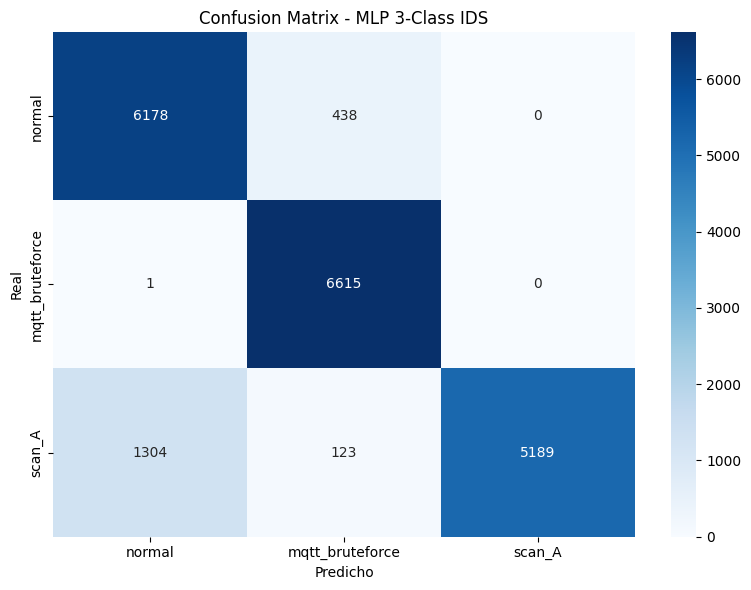

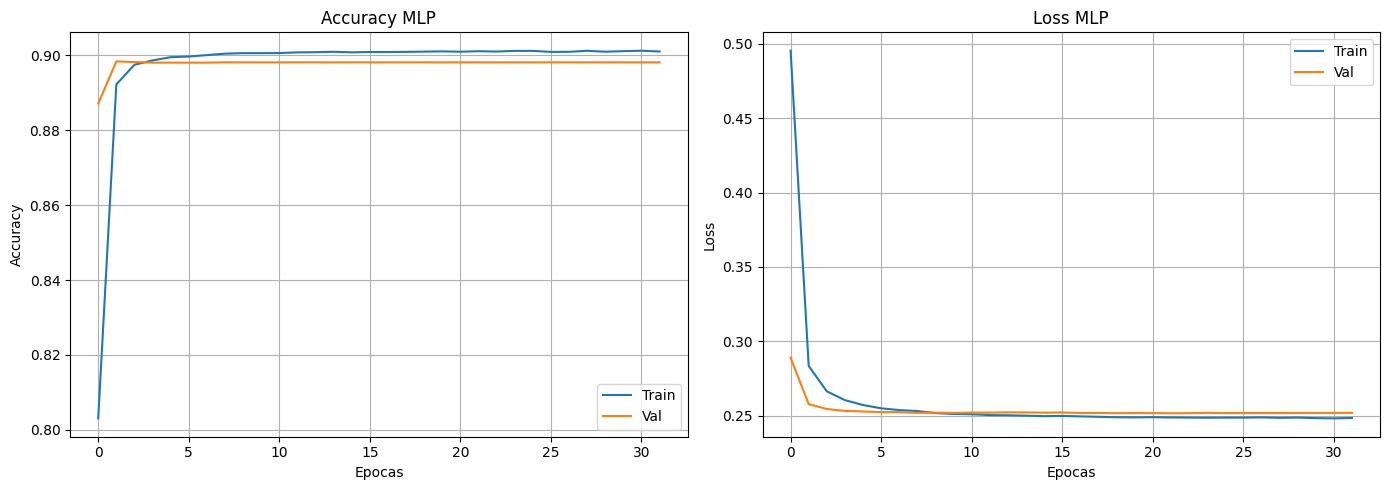


Fusionando BatchNorm en pesos Dense...
  W1: (13, 32), b1: (32,)
  W2: (32, 16), b2: (16,)
  W3: (16, 8), b3: (8,)
  W4: (8, 3), b4: (3,)

Exportacion completa:
  /content/cnn1d_outputs/model_weights.h
  /content/cnn1d_outputs/scaler_params.json
  /content/cnn1d_outputs/label_map.json
  /content/cnn1d_outputs/ids_3class.keras
  /content/cnn1d_outputs/ids_3class.h5
  /content/cnn1d_outputs/ids_3class.weights.h5
  /content/cnn1d_outputs/confusion_matrix.png
  /content/cnn1d_outputs/training_curves.png

Accuracy : 0.9060
F1 Score : 0.9049


In [1]:
# -*- coding: utf-8 -*-
import os
import json
import random
import warnings
from pathlib import Path

os.environ["KERAS_BACKEND"] = "tensorflow"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

# ============================================================
# 1. RUTAS
# ============================================================
# Si subiste los CSV manualmente a Colab, deja esto así:
DATA_DIR = Path("/content").resolve()

# Carpeta de salida separada
OUTPUT_DIR = Path("/content/cnn1d_outputs").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    "uniflow_normal.csv",
    "uniflow_mqtt_bruteforce.csv",
    "uniflow_scan_A.csv",
]

missing = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"No encontré estos archivos en {DATA_DIR}: {missing}")

print("DATA_DIR   =", DATA_DIR)
print("OUTPUT_DIR =", OUTPUT_DIR)

# ============================================================
# 2. CARGAR DATOS
# ============================================================
print("\nCargando datos...")
df_normal = pd.read_csv(DATA_DIR / "uniflow_normal.csv", low_memory=False)
df_bruteforce = pd.read_csv(DATA_DIR / "uniflow_mqtt_bruteforce.csv", low_memory=False)
df_scan = pd.read_csv(DATA_DIR / "uniflow_scan_A.csv", low_memory=False)

df_normal["class_label"] = 0
df_bruteforce["class_label"] = 1
df_scan["class_label"] = 2

print(f"  Normal:          {len(df_normal)}")
print(f"  MQTT Bruteforce: {len(df_bruteforce)}")
print(f"  Scan A:          {len(df_scan)}")

# ============================================================
# 3. FEATURES
# ============================================================
FLOW_FEATURES = [
    "num_pkts", "mean_iat", "std_iat", "min_iat", "max_iat",
    "mean_pkt_len", "num_bytes", "num_psh_flags", "num_rst_flags",
    "num_urg_flags", "std_pkt_len", "min_pkt_len", "max_pkt_len",
]
TARGET = "class_label"
CLASS_NAMES = ["normal", "mqtt_bruteforce", "scan_A"]
NUM_CLASSES = 3
FEATURE_COUNT = len(FLOW_FEATURES)

# ============================================================
# 4. BALANCEAR CLASES
# ============================================================
min_count = min(len(df_normal), len(df_bruteforce), len(df_scan))
print(f"\nBalanceando clases a {min_count} muestras cada una...")

df_normal_s = df_normal.sample(n=min_count, random_state=SEED)
df_bruteforce_s = df_bruteforce.sample(n=min_count, random_state=SEED)
df_scan_s = df_scan.sample(n=min_count, random_state=SEED)

df = pd.concat([df_normal_s, df_bruteforce_s, df_scan_s], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print(f"Dataset final: {df.shape}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {(df[TARGET] == i).sum()}")

# ============================================================
# 5. SPLIT Y ESCALAR
# ============================================================
X = df[FLOW_FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

print(f"\nTrain: {X_train_sc.shape} | Test: {X_test_sc.shape}")

# ============================================================
# 6. MODELO MLP
# ============================================================
print(f"\nArquitectura MLP: {FEATURE_COUNT} -> 32 -> BN -> 16 -> BN -> 8 -> {NUM_CLASSES}")

model = keras.Sequential([
    layers.Input(shape=(FEATURE_COUNT,), name="input_features"),
    layers.Dense(32, activation="relu", name="dense_1"),
    layers.BatchNormalization(name="bn_1"),
    layers.Dropout(0.3, name="drop_1"),
    layers.Dense(16, activation="relu", name="dense_2"),
    layers.BatchNormalization(name="bn_2"),
    layers.Dropout(0.2, name="drop_2"),
    layers.Dense(8, activation="relu", name="dense_3"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="dense_out"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    jit_compile=False,
)

model.summary()

# ============================================================
# 7. ENTRENAMIENTO
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
)

checkpoint_path = OUTPUT_DIR / "ids_3class_best.keras"
model_ckpt = callbacks.ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor="val_loss",
    save_best_only=True,
)

history = model.fit(
    X_train_sc,
    y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr, model_ckpt],
    verbose=1,
)

# ============================================================
# 8. EVALUACIÓN
# ============================================================
y_pred = model.predict(X_test_sc, verbose=0).argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"\nAccuracy: {acc:.4f}")
print(f"F1 (weighted): {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Confusion Matrix - MLP 3-Class IDS")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy MLP")
axes[0].set_xlabel("Epocas")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss MLP")
axes[1].set_xlabel("Epocas")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=200)
plt.show()

# ============================================================
# 9. EXPORTAR model_weights.h
# ============================================================
def fuse_bn(dense_layer, bn_layer):
    W, b = dense_layer.get_weights()
    gamma, beta, moving_mean, moving_var = bn_layer.get_weights()
    eps = bn_layer.epsilon

    scale = gamma / np.sqrt(moving_var + eps)
    W_fused = W * scale[np.newaxis, :]
    b_fused = (b - moving_mean) * scale + beta
    return W_fused, b_fused


def format_array_1d(name, arr):
    vals = ", ".join(f"{float(v):.6f}f" for v in arr.flatten())
    return f"static const float {name}[{len(arr.flatten())}] = {{{vals}}};\n"


def format_array_2d(name, arr):
    rows, cols = arr.shape
    lines = [f"static const float {name}[{rows}][{cols}] = {{"]
    for i in range(rows):
        vals = ", ".join(f"{float(v):.6f}f" for v in arr[i])
        comma = "," if i < rows - 1 else ""
        lines.append(f"  {{{vals}}}{comma}")
    lines.append("};\n")
    return "\n".join(lines)


print("\nFusionando BatchNorm en pesos Dense...")

W1_f, b1_f = fuse_bn(model.get_layer("dense_1"), model.get_layer("bn_1"))
W2_f, b2_f = fuse_bn(model.get_layer("dense_2"), model.get_layer("bn_2"))
W3_raw, b3_raw = model.get_layer("dense_3").get_weights()
W4_raw, b4_raw = model.get_layer("dense_out").get_weights()

print(f"  W1: {W1_f.shape}, b1: {b1_f.shape}")
print(f"  W2: {W2_f.shape}, b2: {b2_f.shape}")
print(f"  W3: {W3_raw.shape}, b3: {b3_raw.shape}")
print(f"  W4: {W4_raw.shape}, b4: {b4_raw.shape}")

header_path = OUTPUT_DIR / "model_weights.h"
with open(header_path, "w", encoding="utf-8") as f:
    f.write("// AUTO-GENERADO - NO EDITAR MANUALMENTE\n")
    f.write("// Modelo: MLP 3 clases para IDS MQTT (TinyML)\n")
    f.write(f"// Clases: {', '.join(CLASS_NAMES)}\n")
    f.write(f"// Arquitectura: {FEATURE_COUNT}->32->16->8->{NUM_CLASSES}\n")
    f.write("// BatchNorm fusionado en Dense layers\n")
    f.write("#pragma once\n\n")

    f.write(f"static const size_t FEATURE_COUNT = {FEATURE_COUNT};\n")
    f.write(f"static const size_t NUM_CLASSES = {NUM_CLASSES};\n\n")

    f.write("// StandardScaler params\n")
    f.write(format_array_1d("scaler_mean", scaler.mean_))
    f.write(format_array_1d("scaler_std", scaler.scale_))
    f.write("\n")

    f.write(f"// Dense 1 (fused BN): ({FEATURE_COUNT}, 32)\n")
    f.write(format_array_2d("W1_base", W1_f))
    f.write(format_array_1d("b1_base", b1_f))
    f.write("\n")

    f.write("// Dense 2 (fused BN): (32, 16)\n")
    f.write(format_array_2d("W2_base", W2_f))
    f.write(format_array_1d("b2_base", b2_f))
    f.write("\n")

    f.write("// Dense 3: (16, 8)\n")
    f.write(format_array_2d("W3_base", W3_raw))
    f.write(format_array_1d("b3_base", b3_raw))
    f.write("\n")

    f.write(f"// Dense out (softmax): (8, {NUM_CLASSES})\n")
    f.write(format_array_2d("W4_base", W4_raw))
    f.write(format_array_1d("b4_base", b4_raw))

# ============================================================
# 10. EXPORTAR scaler, label_map y modelos
# ============================================================
with open(OUTPUT_DIR / "scaler_params.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "mean": scaler.mean_.tolist(),
            "std": scaler.scale_.tolist(),
            "features": FLOW_FEATURES,
            "input_shape": [FEATURE_COUNT],
            "model_type": "MLP",
            "tensorflow_version": tf.__version__,
            "keras_version": keras.__version__,
        },
        f,
        indent=2,
    )

with open(OUTPUT_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({name: i for i, name in enumerate(CLASS_NAMES)}, f, indent=2)

keras_path = OUTPUT_DIR / "ids_3class.keras"
h5_path = OUTPUT_DIR / "ids_3class.h5"
weights_path = OUTPUT_DIR / "ids_3class.weights.h5"

model.save(keras_path)
model.save(h5_path, include_optimizer=False)
model.save_weights(weights_path)

print("\nExportacion completa:")
print(" ", header_path)
print(" ", OUTPUT_DIR / "scaler_params.json")
print(" ", OUTPUT_DIR / "label_map.json")
print(" ", keras_path)
print(" ", h5_path)
print(" ", weights_path)
print(" ", OUTPUT_DIR / "confusion_matrix.png")
print(" ", OUTPUT_DIR / "training_curves.png")
print(f"\nAccuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")


In [2]:
import zipfile
import os
from google.colab import files

folder_to_compress = '/content/cnn1d_outputs'
output_zip_file = '/content/cnn1d_outputs.zip'

# Crear el archivo ZIP
with zipfile.ZipFile(output_zip_file, 'w') as zipf:
    for root, dirs, files_in_folder in os.walk(folder_to_compress):
        for file in files_in_folder:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, folder_to_compress))

print(f"Carpeta '{folder_to_compress}' comprimida en '{output_zip_file}'")

# Descargar el archivo ZIP
files.download(output_zip_file)

Carpeta '/content/cnn1d_outputs' comprimida en '/content/cnn1d_outputs.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Tiny Transformer (Auto-Atención Tabular)

In [3]:
# -*- coding: utf-8 -*-
import os
import json
import random
import warnings
from pathlib import Path

os.environ["KERAS_BACKEND"] = "tensorflow"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

# ============================================================
# 1. RUTAS
# ============================================================
DATA_DIR = Path("/content").resolve()

OUTPUT_DIR = Path("/content/transformer_outputs").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    "uniflow_normal.csv",
    "uniflow_mqtt_bruteforce.csv",
    "uniflow_scan_A.csv",
]

missing = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"No encontré estos archivos en {DATA_DIR}: {missing}")

# ============================================================
# 2. CARGAR Y BALANCEAR DATOS
# ============================================================
print("\nCargando datos...")
df_normal = pd.read_csv(DATA_DIR / "uniflow_normal.csv", low_memory=False)
df_bruteforce = pd.read_csv(DATA_DIR / "uniflow_mqtt_bruteforce.csv", low_memory=False)
df_scan = pd.read_csv(DATA_DIR / "uniflow_scan_A.csv", low_memory=False)

df_normal["class_label"] = 0
df_bruteforce["class_label"] = 1
df_scan["class_label"] = 2

min_count = min(len(df_normal), len(df_bruteforce), len(df_scan))
print(f"Balanceando clases a {min_count} muestras cada una...")

df = pd.concat([
    df_normal.sample(n=min_count, random_state=SEED),
    df_bruteforce.sample(n=min_count, random_state=SEED),
    df_scan.sample(n=min_count, random_state=SEED)
], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

FLOW_FEATURES = [
    "num_pkts", "mean_iat", "std_iat", "min_iat", "max_iat",
    "mean_pkt_len", "num_bytes", "num_psh_flags", "num_rst_flags",
    "num_urg_flags", "std_pkt_len", "min_pkt_len", "max_pkt_len",
]
TARGET = "class_label"
CLASS_NAMES = ["normal", "mqtt_bruteforce", "scan_A"]
NUM_CLASSES = 3
FEATURE_COUNT = len(FLOW_FEATURES)

# ============================================================
# 3. SPLIT Y ESCALAR
# ============================================================
X = df[FLOW_FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

# ============================================================
# 4. ARQUITECTURA TINY TRANSFORMER
# ============================================================
print(f"\nArquitectura Tiny Transformer: {FEATURE_COUNT} features -> MHA -> GAP -> 8 -> 3")

# Hyperparametros del Transformer
d_model = 8       # Dimension de embedding por característica
num_heads = 2     # Cabezas de atención
key_dim = 4       # Dimensión matemática de cada cabeza

inputs = layers.Input(shape=(FEATURE_COUNT,), name="input_features")

# Paso 1: Tratar cada característica (columna) como un "Token" (secuencia de longitud 13)
x = layers.Reshape((FEATURE_COUNT, 1))(inputs)

# Paso 2: Proyectar el token numérico a un vector de tamaño d_model (Feature Embedding)
x = layers.Dense(d_model, activation="linear", name="feature_embed")(x)

# Paso 3: Tiny Self-Attention (Las características se comunican entre sí)
attn_out = layers.MultiHeadAttention(
    num_heads=num_heads,
    key_dim=key_dim,
    dropout=0.1,
    name="self_attention"
)(x, x)

# Paso 4: Conexión Residual y Normalización
x = layers.Add(name="residual_add")([x, attn_out])
x = layers.LayerNormalization(name="layer_norm")(x)

# Paso 5: Condensar la secuencia de 13 tokens en un solo vector de tamaño d_model
x = layers.GlobalAveragePooling1D(name="gap")(x)

# Paso 6: Capas Densas para el Federated Learning
# Estas son las capas "dense_1" y "dense_out" que se actualizarán en el PC
x = layers.Dense(8, activation="relu", name="dense_1")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="dense_out")(x)

model = keras.Model(inputs, outputs, name="tiny_transformer")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ============================================================
# 5. ENTRENAMIENTO
# ============================================================
checkpoint_path = OUTPUT_DIR / "ids_3class_transformer.keras"
callbacks_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    callbacks.ModelCheckpoint(filepath=str(checkpoint_path), monitor="val_loss", save_best_only=True)
]

history = model.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=100, batch_size=256,
    callbacks=callbacks_list, verbose=1
)

# ============================================================
# 6. EXPORTAR PESOS A C++ (model_weights.h)
# ============================================================
def format_array_1d(name, arr):
    vals = ", ".join(f"{float(v):.6f}f" for v in arr.flatten())
    return f"static const float {name}[{len(arr.flatten())}] = {{{vals}}};\n"

def format_array_2d(name, arr):
    rows, cols = arr.shape
    lines = [f"static const float {name}[{rows}][{cols}] = {{"]
    for i in range(rows):
        vals = ", ".join(f"{float(v):.6f}f" for v in arr[i])
        comma = "," if i < rows - 1 else ""
        lines.append(f"  {{{vals}}}{comma}")
    lines.append("};\n")
    return "\n".join(lines)

def format_array_3d(name, arr):
    d1, d2, d3 = arr.shape
    lines = [f"static const float {name}[{d1}][{d2}][{d3}] = {{"]
    for i in range(d1):
        lines.append("  {")
        for j in range(d2):
            vals = ", ".join(f"{float(v):.6f}f" for v in arr[i][j])
            comma = "," if j < d2 - 1 else ""
            lines.append(f"    {{{vals}}}{comma}")
        comma_outer = "," if i < d1 - 1 else ""
        lines.append(f"  }}{comma_outer}")
    lines.append("};\n")
    return "\n".join(lines)

print("\nExtrayendo pesos del Transformer para C++...")

# Feature Embedding
W_embed, b_embed = model.get_layer("feature_embed").get_weights()

# Multi-Head Attention (Keras 3 get_weights devuelve 8 arreglos: Wq, bq, Wk, bk, Wv, bv, Wo, bo)
mha_weights = model.get_layer("self_attention").get_weights()
Wq, bq, Wk, bk, Wv, bv, Wo, bo = mha_weights

# Layer Norm
gamma_ln, beta_ln = model.get_layer("layer_norm").get_weights()

# Dense FL Layers
W_d1, b_d1 = model.get_layer("dense_1").get_weights()
W_do, b_do = model.get_layer("dense_out").get_weights()

header_path = OUTPUT_DIR / "model_weights_transformer.h"
with open(header_path, "w", encoding="utf-8") as f:
    f.write("// AUTO-GENERADO - TINY TRANSFORMER FL\n")
    f.write("#pragma once\n\n")

    f.write(f"static const size_t FEATURE_COUNT = {FEATURE_COUNT};\n")
    f.write(f"static const size_t NUM_CLASSES = {NUM_CLASSES};\n\n")
    f.write(f"static const size_t D_MODEL = {d_model};\n")
    f.write(f"static const size_t NUM_HEADS = {num_heads};\n")
    f.write(f"static const size_t KEY_DIM = {key_dim};\n\n")

    f.write("// StandardScaler\n")
    f.write(format_array_1d("scaler_mean", scaler.mean_))
    f.write(format_array_1d("scaler_std", scaler.scale_))
    f.write("\n")

    f.write("// 1. Feature Embedding: (1, 8)\n")
    f.write(format_array_2d("W_embed", W_embed))
    f.write(format_array_1d("b_embed", b_embed))
    f.write("\n")

    f.write("// 2. Multi-Head Attention (W: d_model x heads x key_dim)\n")
    f.write(format_array_3d("Wq", Wq))
    f.write(format_array_2d("bq", bq))
    f.write(format_array_3d("Wk", Wk))
    f.write(format_array_2d("bk", bk))
    f.write(format_array_3d("Wv", Wv))
    f.write(format_array_2d("bv", bv))
    f.write(format_array_3d("Wo", Wo)) # (heads, key_dim, d_model)
    f.write(format_array_1d("bo", bo))
    f.write("\n")

    f.write("// 3. Layer Normalization\n")
    f.write(format_array_1d("gamma_ln", gamma_ln))
    f.write(format_array_1d("beta_ln", beta_ln))
    f.write("\n")

    f.write("// 4. Dense 1 (Federated)\n")
    f.write(format_array_2d("W_d1_base", W_d1))
    f.write(format_array_1d("b_d1_base", b_d1))
    f.write("\n")

    f.write("// 5. Dense Out (Federated)\n")
    f.write(format_array_2d("W_do_base", W_do))
    f.write(format_array_1d("b_do_base", b_do))

print("Header generado en:", header_path)

import zipfile
from google.colab import files
zip_path = "/content/transformer_outputs.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files_in_folder in os.walk(OUTPUT_DIR):
        for file in files_in_folder:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, OUTPUT_DIR))
files.download(zip_path)



TensorFlow: 2.19.0
Keras: 3.13.2

Cargando datos...
Balanceando clases a 33079 muestras cada una...

Arquitectura Tiny Transformer: 13 features -> MHA -> GAP -> 8 -> 3


Model: "tiny_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 13, 1)     │          0 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_embed       │ (None, 13, 8)     │         16 │ reshape[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 13, 8)     │        288 │ feature_embed[0]… │
│ (MultiHeadAttentio… │                   │            │ feature_embed[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 13, 8)     │          0 │ feature_embed[0]… │
│                     │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 13, 8)     │         16 │ residual_add[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 8)         │          0 │ layer_norm[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │         72 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_out (Dense)   │ (None, 3)         │         27 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 419 (1.64 KB)

 Trainable params: 419 (1.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7147 - loss: 0.7027 - val_accuracy: 0.8731 - val_loss: 0.4674 - learning_rate: 0.0010
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8686 - loss: 0.4439 - val_accuracy: 0.8731 - val_loss: 0.3920 - learning_rate: 0.0010
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8719 - loss: 0.3938 - val_accuracy: 0.8730 - val_loss: 0.3691 - learning_rate: 0.0010
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8716 - loss: 0.3748 - val_accuracy: 0.8730 - val_loss: 0.3574 - learning_rate: 0.0010
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8686 - loss: 0.3595 - val_accuracy: 0.8730 - val_loss: 0.3348 - learning_rate: 0.0010
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8778 - loss: 0.3400 - val_accuracy: 0.8737 - val_loss: 0.3177 - learning_rate: 0.0010
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8877 - loss: 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Version 2 Con graficas y resultados

TensorFlow: 2.19.0
Keras: 3.13.2

Cargando datos...
Balanceando clases a 33079 muestras cada una...

Arquitectura Tiny Transformer: 13 features -> MHA -> GAP -> 8 -> 3


Model: "tiny_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 13, 1)     │          0 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_embed       │ (None, 13, 8)     │         16 │ reshape_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 13, 8)     │        288 │ feature_embed[0]… │
│ (MultiHeadAttentio… │                   │            │ feature_embed[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 13, 8)     │          0 │ feature_embed[0]… │
│                     │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 13, 8)     │         16 │ residual_add[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 8)         │          0 │ layer_norm[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │         72 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_out (Dense)   │ (None, 3)         │         27 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 419 (1.64 KB)

 Trainable params: 419 (1.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7147 - loss: 0.7027 - val_accuracy: 0.8731 - val_loss: 0.4674 - learning_rate: 0.0010
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8686 - loss: 0.4439 - val_accuracy: 0.8731 - val_loss: 0.3920 - learning_rate: 0.0010
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8719 - loss: 0.3938 - val_accuracy: 0.8730 - val_loss: 0.3691 - learning_rate: 0.0010
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8716 - loss: 0.3748 - val_accuracy: 0.8730 - val_loss: 0.3574 - learning_rate: 0.0010
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8686 - loss: 0.3595 - val_accuracy: 0.8730 - val_loss: 0.3348 - learning_rate: 0.0010
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8778 - loss: 0.3400 - val_accuracy: 0.8737 - val_loss: 0.3177 - learning_rate: 0.0010
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8877 - loss: 

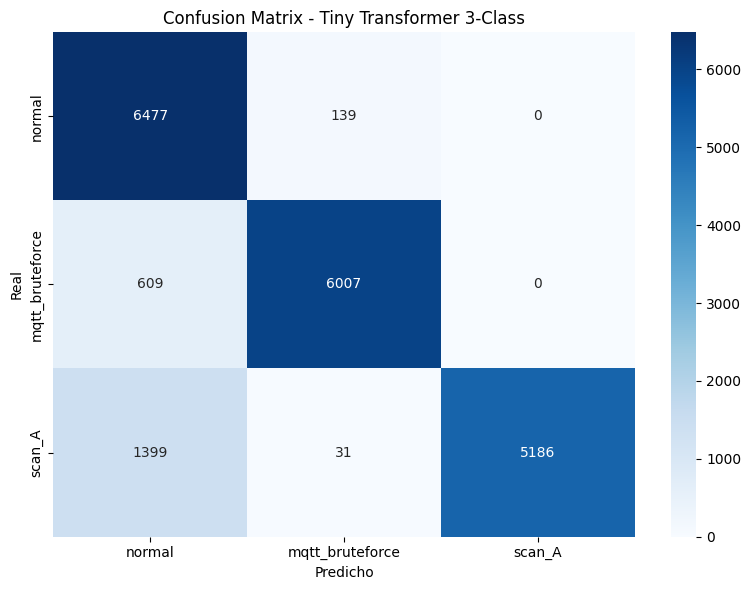

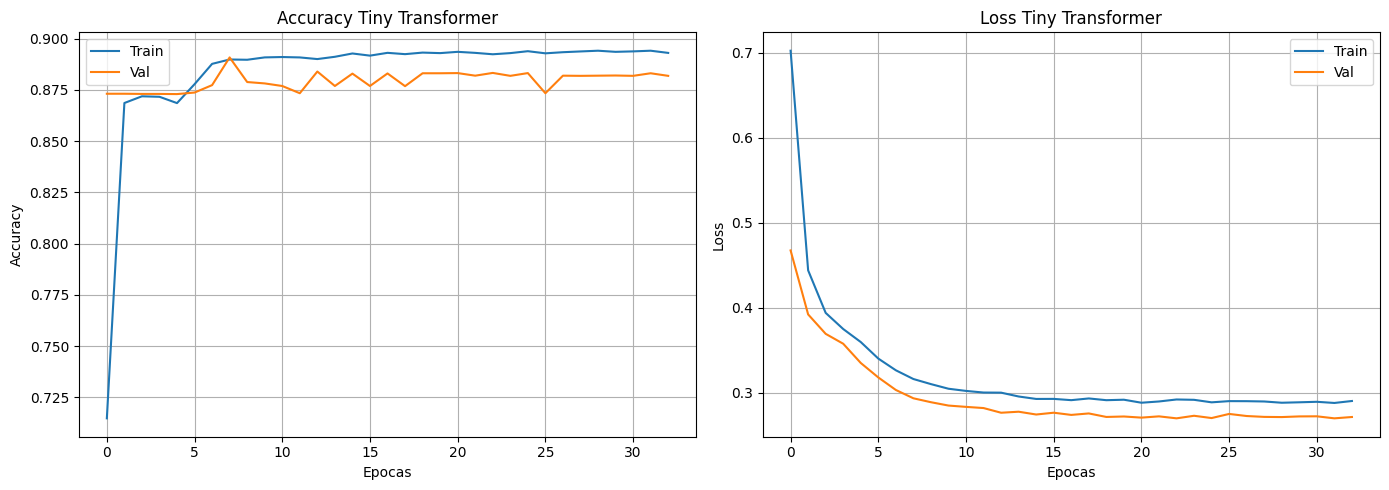


Extrayendo pesos del Transformer para C++...

Exportacion completa:
  /content/transformer_outputs_2/model_weights_transformer.h
  /content/transformer_outputs_2/scaler_params.json
  /content/transformer_outputs_2/label_map.json
  /content/transformer_outputs_2/ids_3class_transformer.keras
  /content/transformer_outputs_2/ids_3class_transformer.h5
  /content/transformer_outputs_2/ids_3class_transformer.weights.h5
  /content/transformer_outputs_2/confusion_matrix.png
  /content/transformer_outputs_2/training_curves.png

Accuracy : 0.8903
F1 Score : 0.8919

Carpeta '/content/transformer_outputs_2' comprimida en '/content/transformer_outputs.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# -*- coding: utf-8 -*-
import os
import json
import random
import warnings
from pathlib import Path

os.environ["KERAS_BACKEND"] = "tensorflow"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

# ============================================================
# 1. RUTAS
# ============================================================
DATA_DIR = Path("/content").resolve()

OUTPUT_DIR = Path("/content/transformer_outputs_2").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    "uniflow_normal.csv",
    "uniflow_mqtt_bruteforce.csv",
    "uniflow_scan_A.csv",
]

missing = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"No encontré estos archivos en {DATA_DIR}: {missing}")

# ============================================================
# 2. CARGAR Y BALANCEAR DATOS
# ============================================================
print("\nCargando datos...")
df_normal = pd.read_csv(DATA_DIR / "uniflow_normal.csv", low_memory=False)
df_bruteforce = pd.read_csv(DATA_DIR / "uniflow_mqtt_bruteforce.csv", low_memory=False)
df_scan = pd.read_csv(DATA_DIR / "uniflow_scan_A.csv", low_memory=False)

df_normal["class_label"] = 0
df_bruteforce["class_label"] = 1
df_scan["class_label"] = 2

min_count = min(len(df_normal), len(df_bruteforce), len(df_scan))
print(f"Balanceando clases a {min_count} muestras cada una...")

df = pd.concat([
    df_normal.sample(n=min_count, random_state=SEED),
    df_bruteforce.sample(n=min_count, random_state=SEED),
    df_scan.sample(n=min_count, random_state=SEED)
], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

FLOW_FEATURES = [
    "num_pkts", "mean_iat", "std_iat", "min_iat", "max_iat",
    "mean_pkt_len", "num_bytes", "num_psh_flags", "num_rst_flags",
    "num_urg_flags", "std_pkt_len", "min_pkt_len", "max_pkt_len",
]
TARGET = "class_label"
CLASS_NAMES = ["normal", "mqtt_bruteforce", "scan_A"]
NUM_CLASSES = 3
FEATURE_COUNT = len(FLOW_FEATURES)

# ============================================================
# 3. SPLIT Y ESCALAR
# ============================================================
X = df[FLOW_FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

# ============================================================
# 4. ARQUITECTURA TINY TRANSFORMER
# ============================================================
print(f"\nArquitectura Tiny Transformer: {FEATURE_COUNT} features -> MHA -> GAP -> 8 -> 3")

d_model = 8
num_heads = 2
key_dim = 4

inputs = layers.Input(shape=(FEATURE_COUNT,), name="input_features")
x = layers.Reshape((FEATURE_COUNT, 1))(inputs)

x = layers.Dense(d_model, activation="linear", name="feature_embed")(x)

attn_out = layers.MultiHeadAttention(
    num_heads=num_heads,
    key_dim=key_dim,
    dropout=0.1,
    name="self_attention"
)(x, x)

x = layers.Add(name="residual_add")([x, attn_out])
x = layers.LayerNormalization(name="layer_norm")(x)

x = layers.GlobalAveragePooling1D(name="gap")(x)

x = layers.Dense(8, activation="relu", name="dense_1")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="dense_out")(x)

model = keras.Model(inputs, outputs, name="tiny_transformer")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ============================================================
# 5. ENTRENAMIENTO
# ============================================================
checkpoint_path = OUTPUT_DIR / "ids_3class_transformer.keras"
callbacks_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    callbacks.ModelCheckpoint(filepath=str(checkpoint_path), monitor="val_loss", save_best_only=True)
]

history = model.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=100, batch_size=256,
    callbacks=callbacks_list, verbose=1
)

# ============================================================
# 6. EVALUACIÓN Y GRÁFICAS
# ============================================================
y_pred = model.predict(X_test_sc, verbose=0).argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"\nAccuracy: {acc:.4f}")
print(f"F1 (weighted): {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - Tiny Transformer 3-Class")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy Tiny Transformer")
axes[0].set_xlabel("Epocas")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss Tiny Transformer")
axes[1].set_xlabel("Epocas")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=200)
plt.show()


# ============================================================
# 7. EXPORTAR PESOS A C++ (model_weights.h)
# ============================================================
def format_array_1d(name, arr):
    vals = ", ".join(f"{float(v):.6f}f" for v in arr.flatten())
    return f"static const float {name}[{len(arr.flatten())}] = {{{vals}}};\n"

def format_array_2d(name, arr):
    rows, cols = arr.shape
    lines = [f"static const float {name}[{rows}][{cols}] = {{"]
    for i in range(rows):
        vals = ", ".join(f"{float(v):.6f}f" for v in arr[i])
        comma = "," if i < rows - 1 else ""
        lines.append(f"  {{{vals}}}{comma}")
    lines.append("};\n")
    return "\n".join(lines)

def format_array_3d(name, arr):
    d1, d2, d3 = arr.shape
    lines = [f"static const float {name}[{d1}][{d2}][{d3}] = {{"]
    for i in range(d1):
        lines.append("  {")
        for j in range(d2):
            vals = ", ".join(f"{float(v):.6f}f" for v in arr[i][j])
            comma = "," if j < d2 - 1 else ""
            lines.append(f"    {{{vals}}}{comma}")
        comma_outer = "," if i < d1 - 1 else ""
        lines.append(f"  }}{comma_outer}")
    lines.append("};\n")
    return "\n".join(lines)

print("\nExtrayendo pesos del Transformer para C++...")

W_embed, b_embed = model.get_layer("feature_embed").get_weights()
mha_weights = model.get_layer("self_attention").get_weights()
Wq, bq, Wk, bk, Wv, bv, Wo, bo = mha_weights
gamma_ln, beta_ln = model.get_layer("layer_norm").get_weights()
W_d1, b_d1 = model.get_layer("dense_1").get_weights()
W_do, b_do = model.get_layer("dense_out").get_weights()

header_path = OUTPUT_DIR / "model_weights_transformer.h"
with open(header_path, "w", encoding="utf-8") as f:
    f.write("// AUTO-GENERADO - TINY TRANSFORMER FL\n")
    f.write("#pragma once\n\n")

    f.write(f"static const size_t FEATURE_COUNT = {FEATURE_COUNT};\n")
    f.write(f"static const size_t NUM_CLASSES = {NUM_CLASSES};\n\n")
    f.write(f"static const size_t D_MODEL = {d_model};\n")
    f.write(f"static const size_t NUM_HEADS = {num_heads};\n")
    f.write(f"static const size_t KEY_DIM = {key_dim};\n\n")

    f.write("// StandardScaler\n")
    f.write(format_array_1d("scaler_mean", scaler.mean_))
    f.write(format_array_1d("scaler_std", scaler.scale_))
    f.write("\n")

    f.write("// 1. Feature Embedding: (1, 8)\n")
    f.write(format_array_2d("W_embed", W_embed))
    f.write(format_array_1d("b_embed", b_embed))
    f.write("\n")

    f.write("// 2. Multi-Head Attention (W: d_model x heads x key_dim)\n")
    f.write(format_array_3d("Wq", Wq))
    f.write(format_array_2d("bq", bq))
    f.write(format_array_3d("Wk", Wk))
    f.write(format_array_2d("bk", bk))
    f.write(format_array_3d("Wv", Wv))
    f.write(format_array_2d("bv", bv))
    f.write(format_array_3d("Wo", Wo)) # (heads, key_dim, d_model)
    f.write(format_array_1d("bo", bo))
    f.write("\n")

    f.write("// 3. Layer Normalization\n")
    f.write(format_array_1d("gamma_ln", gamma_ln))
    f.write(format_array_1d("beta_ln", beta_ln))
    f.write("\n")

    f.write("// 4. Dense 1 (Federated)\n")
    f.write(format_array_2d("W_d1_base", W_d1))
    f.write(format_array_1d("b_d1_base", b_d1))
    f.write("\n")

    f.write("// 5. Dense Out (Federated)\n")
    f.write(format_array_2d("W_do_base", W_do))
    f.write(format_array_1d("b_do_base", b_do))


# ============================================================
# 8. EXPORTAR JSONs Y ARCHIVOS FINALES
# ============================================================
with open(OUTPUT_DIR / "scaler_params.json", "w", encoding="utf-8") as f:
    json.dump({
        "mean": scaler.mean_.tolist(),
        "std": scaler.scale_.tolist(),
        "features": FLOW_FEATURES,
        "input_shape": [FEATURE_COUNT],
        "model_type": "TINY_TRANSFORMER",
        "tensorflow_version": tf.__version__,
        "keras_version": keras.__version__,
    }, f, indent=2)

with open(OUTPUT_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({name: i for i, name in enumerate(CLASS_NAMES)}, f, indent=2)

h5_path = OUTPUT_DIR / "ids_3class_transformer.h5"
weights_path = OUTPUT_DIR / "ids_3class_transformer.weights.h5"

model.save(h5_path, include_optimizer=False)
model.save_weights(weights_path)

print("\nExportacion completa:")
print(" ", header_path)
print(" ", OUTPUT_DIR / "scaler_params.json")
print(" ", OUTPUT_DIR / "label_map.json")
print(" ", checkpoint_path)
print(" ", h5_path)
print(" ", weights_path)
print(" ", OUTPUT_DIR / "confusion_matrix.png")
print(" ", OUTPUT_DIR / "training_curves.png")
print(f"\nAccuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")

import zipfile
from google.colab import files
zip_path = "/content/transformer_outputs.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files_in_folder in os.walk(OUTPUT_DIR):
        for file in files_in_folder:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, OUTPUT_DIR))
print(f"\nCarpeta '{OUTPUT_DIR}' comprimida en '{zip_path}'")
files.download(zip_path)


## Residual-MLP

TensorFlow: 2.19.0
Keras: 3.13.2

Cargando datos...
Balanceando clases a 33079 muestras cada una...

Arquitectura Residual-MLP: 13 -> 32 -> [ResBlock 32] -> 8 -> 3


Model: "residual_mlp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_in (Dense)    │ (None, 32)        │        448 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_in               │ (None, 32)        │        128 │ dense_in[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32)        │          0 │ bn_in[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_res1_a        │ (None, 32)        │      1,056 │ activation[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_res1_a           │ (None, 32)        │        128 │ dense_res1_a[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32)        │          0 │ bn_res1_a[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_res1_b        │ (None, 32)        │      1,056 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32)        │          0 │ activation[0][0], │
│                     │                   │            │ dense_res1_b[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_res1_b           │ (None, 32)        │        128 │ add_1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32)        │          0 │ bn_res1_b[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        264 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_out (Dense)   │ (None, 3)         │         27 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,235 (12.64 KB)

 Trainable params: 3,043 (11.89 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.8489 - loss: 0.4256 - val_accuracy: 0.8975 - val_loss: 0.2955 - learning_rate: 0.0010
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8996 - loss: 0.2663 - val_accuracy: 0.8974 - val_loss: 0.2688 - learning_rate: 0.0010
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9005 - loss: 0.2572 - val_accuracy: 0.8975 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9012 - loss: 0.2532 - val_accuracy: 0.8976 - val_loss: 0.2569 - learning_rate: 0.0010
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9012 - loss: 0.2521 - val_accuracy: 0.8975 - val_loss: 0.2555 - learning_rate: 0.0010
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9015 - loss: 0.2504 - val_accuracy: 0.8975 - val_loss: 0.2547 - learning_rate: 0.0010
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9017 - loss: 

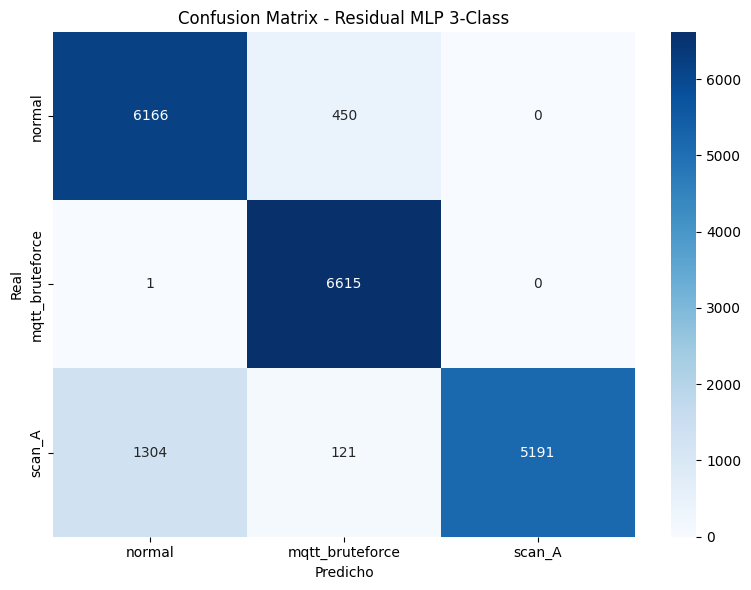

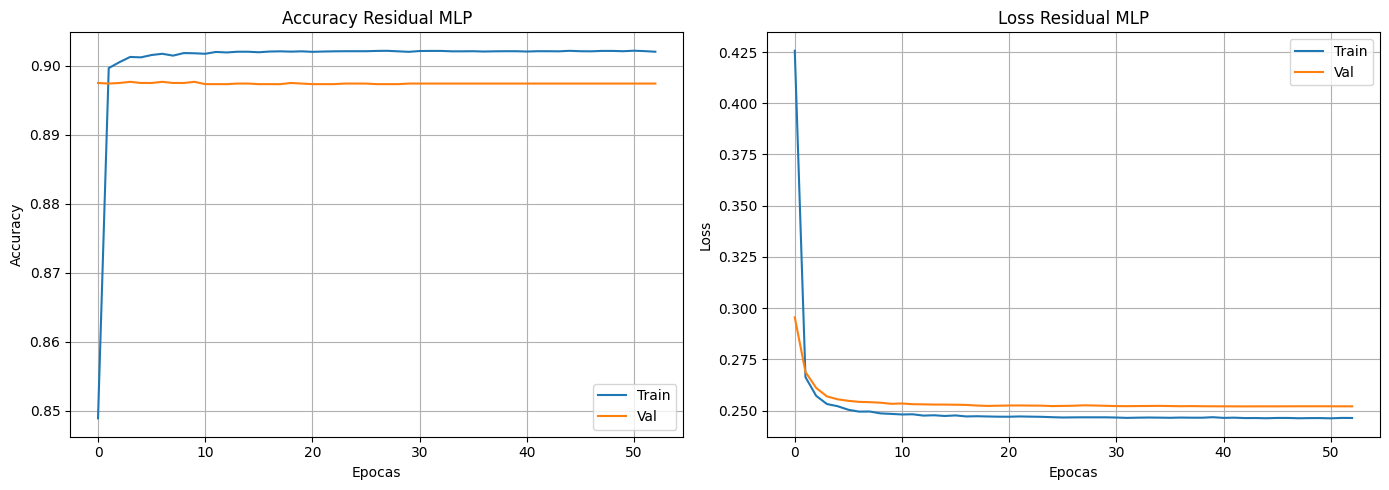


Fusionando BatchNorm en pesos Dense para C++...

Exportacion completa:
  /content/Residual-MLP_outputs/model_weights.h
  /content/Residual-MLP_outputs/scaler_params.json
  /content/Residual-MLP_outputs/label_map.json

  /content/Residual-MLP_outputs/ids_3class.keras
  /content/Residual-MLP_outputs/ids_3class.h5
  /content/Residual-MLP_outputs/ids_3class.weights.h5
  /content/Residual-MLP_outputs/confusion_matrix.png
  /content/Residual-MLP_outputs/training_curves.png

Carpeta '/content/cnn1d_outputs' comprimida en '/content/cnn1d_outputs.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# -*- coding: utf-8 -*-
import os
import json
import random
import warnings
from pathlib import Path

os.environ["KERAS_BACKEND"] = "tensorflow"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

# ============================================================
# 1. RUTAS
# ============================================================
DATA_DIR = Path("/content").resolve()

OUTPUT_DIR = Path("/content/Residual-MLP_outputs").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    "uniflow_normal.csv",
    "uniflow_mqtt_bruteforce.csv",
    "uniflow_scan_A.csv",
]

missing = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"No encontré estos archivos en {DATA_DIR}: {missing}")

# ============================================================
# 2. CARGAR Y BALANCEAR DATOS
# ============================================================
print("\nCargando datos...")
df_normal = pd.read_csv(DATA_DIR / "uniflow_normal.csv", low_memory=False)
df_bruteforce = pd.read_csv(DATA_DIR / "uniflow_mqtt_bruteforce.csv", low_memory=False)
df_scan = pd.read_csv(DATA_DIR / "uniflow_scan_A.csv", low_memory=False)

df_normal["class_label"] = 0
df_bruteforce["class_label"] = 1
df_scan["class_label"] = 2

min_count = min(len(df_normal), len(df_bruteforce), len(df_scan))
print(f"Balanceando clases a {min_count} muestras cada una...")

df = pd.concat([
    df_normal.sample(n=min_count, random_state=SEED),
    df_bruteforce.sample(n=min_count, random_state=SEED),
    df_scan.sample(n=min_count, random_state=SEED)
], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

FLOW_FEATURES = [
    "num_pkts", "mean_iat", "std_iat", "min_iat", "max_iat",
    "mean_pkt_len", "num_bytes", "num_psh_flags", "num_rst_flags",
    "num_urg_flags", "std_pkt_len", "min_pkt_len", "max_pkt_len",
]
TARGET = "class_label"
CLASS_NAMES = ["normal", "mqtt_bruteforce", "scan_A"]
NUM_CLASSES = 3
FEATURE_COUNT = len(FLOW_FEATURES)

# ============================================================
# 3. SPLIT Y ESCALAR
# ============================================================
X = df[FLOW_FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

# ============================================================
# 4. ARQUITECTURA RESIDUAL-MLP
# ============================================================
print(f"\nArquitectura Residual-MLP: {FEATURE_COUNT} -> 32 -> [ResBlock 32] -> 8 -> 3")

inputs = layers.Input(shape=(FEATURE_COUNT,), name="input_features")

# Proyección inicial (Para estandarizar el tamaño de la matriz a 32)
x = layers.Dense(32, activation="linear", name="dense_in")(inputs)
x = layers.BatchNormalization(name="bn_in")(x)
x = layers.Activation("relu")(x)

# --- INICIO DEL BLOQUE RESIDUAL ---
# Ruta Alterna (Las matemáticas complejas)
res1 = layers.Dense(32, activation="linear", name="dense_res1_a")(x)
res1 = layers.BatchNormalization(name="bn_res1_a")(res1)
res1 = layers.Activation("relu")(res1)
res1 = layers.Dropout(0.3)(res1)

res1 = layers.Dense(32, activation="linear", name="dense_res1_b")(res1)

# Conexión Residual (El "Atajo" que evita que los gradientes mueran en el FL)
x = layers.Add(name="add_1")([x, res1])
x = layers.BatchNormalization(name="bn_res1_b")(x)
x = layers.Activation("relu")(x)
# --- FIN DEL BLOQUE RESIDUAL ---

x = layers.Dropout(0.2)(x)

# Capas Federadas (Las que el PC promediará con FedAvg)
x = layers.Dense(8, activation="relu", name="dense_1")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="dense_out")(x)

model = keras.Model(inputs, outputs, name="residual_mlp")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ============================================================
# 5. ENTRENAMIENTO
# ============================================================
keras_path = OUTPUT_DIR / "ids_3class.keras"
callbacks_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    callbacks.ModelCheckpoint(filepath=str(keras_path), monitor="val_loss", save_best_only=True)
]

history = model.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=100, batch_size=256,
    callbacks=callbacks_list, verbose=1
)

# ============================================================
# 6. EVALUACIÓN Y GRÁFICAS
# ============================================================
y_pred = model.predict(X_test_sc, verbose=0).argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"\nAccuracy: {acc:.4f}")
print(f"F1 (weighted): {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - Residual MLP 3-Class")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy Residual MLP")
axes[0].set_xlabel("Epocas")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss Residual MLP")
axes[1].set_xlabel("Epocas")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=200)
plt.show()


# ============================================================
# 7. EXPORTAR PESOS A C++ (model_weights.h)
# ============================================================
def fuse_bn(dense_layer, bn_layer):
    W, b = dense_layer.get_weights()
    gamma, beta, moving_mean, moving_var = bn_layer.get_weights()
    eps = bn_layer.epsilon
    scale = gamma / np.sqrt(moving_var + eps)
    W_fused = W * scale[np.newaxis, :]
    b_fused = (b - moving_mean) * scale + beta
    return W_fused, b_fused

def format_array_1d(name, arr):
    vals = ", ".join(f"{float(v):.6f}f" for v in arr.flatten())
    return f"static const float {name}[{len(arr.flatten())}] = {{{vals}}};\n"

def format_array_2d(name, arr):
    rows, cols = arr.shape
    lines = [f"static const float {name}[{rows}][{cols}] = {{"]
    for i in range(rows):
        vals = ", ".join(f"{float(v):.6f}f" for v in arr[i])
        comma = "," if i < rows - 1 else ""
        lines.append(f"  {{{vals}}}{comma}")
    lines.append("};\n")
    return "\n".join(lines)

print("\nFusionando BatchNorm en pesos Dense para C++...")

W_in_f, b_in_f = fuse_bn(model.get_layer("dense_in"), model.get_layer("bn_in"))
W_r1a_f, b_r1a_f = fuse_bn(model.get_layer("dense_res1_a"), model.get_layer("bn_res1_a"))
W_r1b_f, b_r1b_f = fuse_bn(model.get_layer("dense_res1_b"), model.get_layer("bn_res1_b"))

W_d1, b_d1 = model.get_layer("dense_1").get_weights()
W_do, b_do = model.get_layer("dense_out").get_weights()

header_path = OUTPUT_DIR / "model_weights.h"
with open(header_path, "w", encoding="utf-8") as f:
    f.write("// AUTO-GENERADO - RESIDUAL MLP FL\n")
    f.write("#pragma once\n\n")

    f.write(f"static const size_t FEATURE_COUNT = {FEATURE_COUNT};\n")
    f.write(f"static const size_t NUM_CLASSES = {NUM_CLASSES};\n\n")

    f.write("// StandardScaler\n")
    f.write(format_array_1d("scaler_mean", scaler.mean_))
    f.write(format_array_1d("scaler_std", scaler.scale_))
    f.write("\n")

    f.write("// 1. Proyeccion Inicial (Fused BN): (13, 32)\n")
    f.write(format_array_2d("W_in", W_in_f))
    f.write(format_array_1d("b_in", b_in_f))
    f.write("\n")

    f.write("// 2. Residual Block A (Fused BN): (32, 32)\n")
    f.write(format_array_2d("W_res_a", W_r1a_f))
    f.write(format_array_1d("b_res_a", b_r1a_f))
    f.write("\n")

    f.write("// 3. Residual Block B (Fused BN): (32, 32)\n")
    f.write(format_array_2d("W_res_b", W_r1b_f))
    f.write(format_array_1d("b_res_b", b_r1b_f))
    f.write("\n")

    f.write("// 4. Dense 1 (Federated): (32, 8)\n")
    f.write(format_array_2d("W_d1_base", W_d1))
    f.write(format_array_1d("b_d1_base", b_d1))
    f.write("\n")

    f.write("// 5. Dense Out (Federated): (8, 3)\n")
    f.write(format_array_2d("W_do_base", W_do))
    f.write(format_array_1d("b_do_base", b_do))

# ============================================================
# 8. EXPORTAR JSONs Y ARCHIVOS FINALES
# ============================================================
with open(OUTPUT_DIR / "scaler_params.json", "w", encoding="utf-8") as f:
    json.dump({
        "mean": scaler.mean_.tolist(),
        "std": scaler.scale_.tolist(),
        "features": FLOW_FEATURES,
        "input_shape": [FEATURE_COUNT],
        "model_type": "RESIDUAL_MLP",
        "tensorflow_version": tf.__version__,
        "keras_version": keras.__version__,
    }, f, indent=2)

with open(OUTPUT_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({name: i for i, name in enumerate(CLASS_NAMES)}, f, indent=2)

h5_path = OUTPUT_DIR / "ids_3class.h5"
weights_path = OUTPUT_DIR / "ids_3class.weights.h5"

model.save(keras_path)
model.save(h5_path, include_optimizer=False)
model.save_weights(weights_path)

print("\nExportacion completa:")
print(f"  {header_path}")
print(f"  {OUTPUT_DIR / 'scaler_params.json'}")
print(f"  {OUTPUT_DIR / 'label_map.json'}")
print("")
print(f"  {keras_path}")
print(f"  {h5_path}")
print(f"  {weights_path}")
print(f"  {OUTPUT_DIR / 'confusion_matrix.png'}")
print(f"  {OUTPUT_DIR / 'training_curves.png'}")


import zipfile
from google.colab import files

folder_to_compress = '/content/Residual-MLP_outputs'
output_zip_file = '/content/Residual-MLP_outputs.zip'

with zipfile.ZipFile(output_zip_file, 'w') as zipf:
    for root, dirs, files_in_folder in os.walk(folder_to_compress):
        for file in files_in_folder:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, folder_to_compress))

print(f"\nCarpeta '{folder_to_compress}' comprimida en '{output_zip_file}'")
files.download(output_zip_file)
